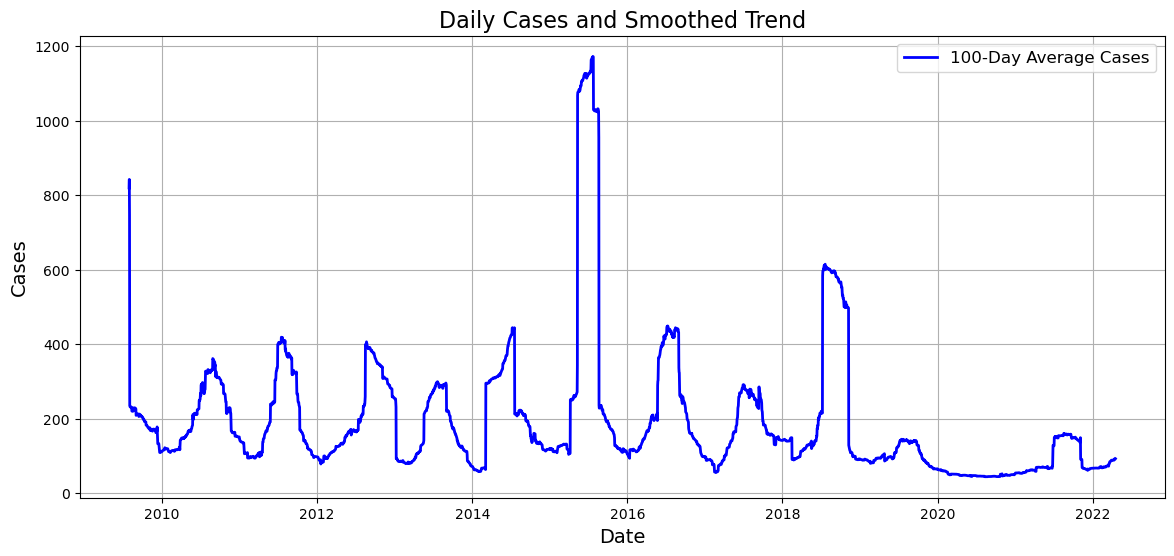

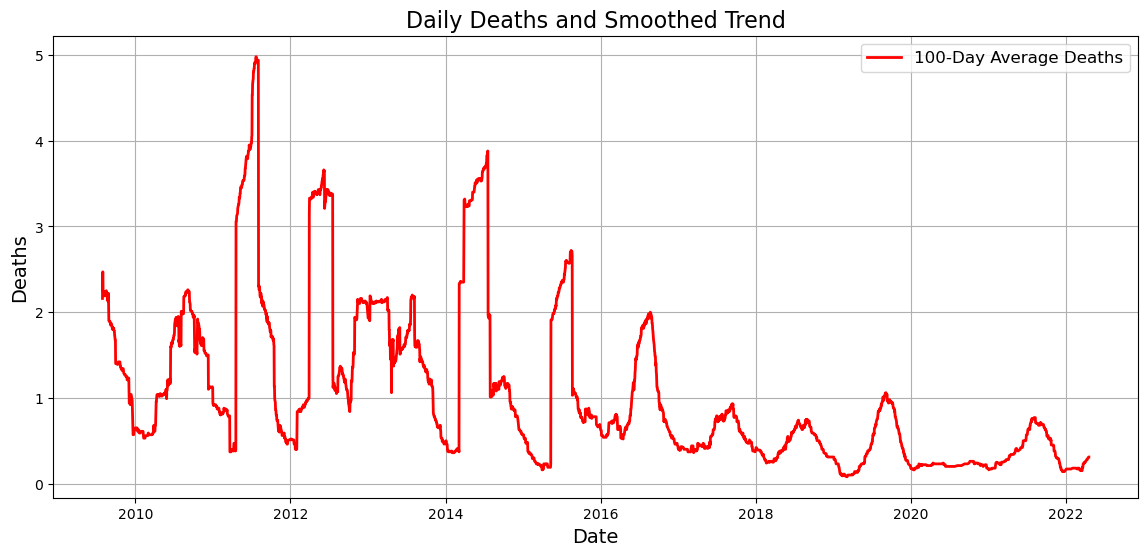

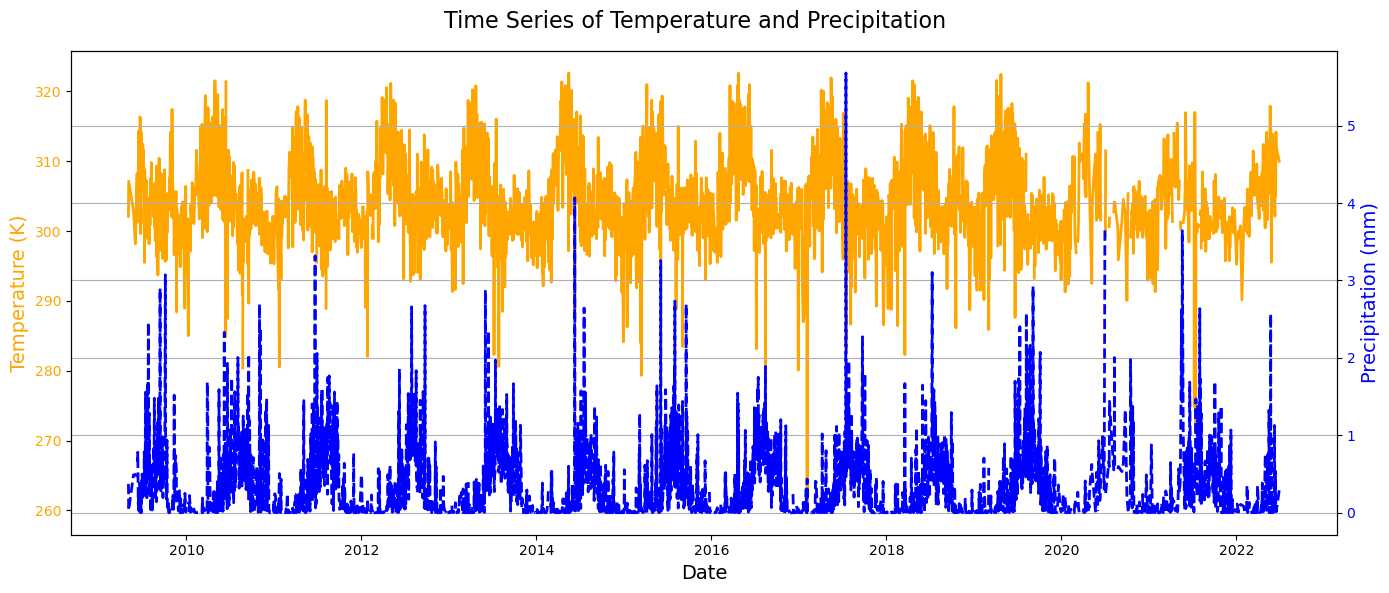

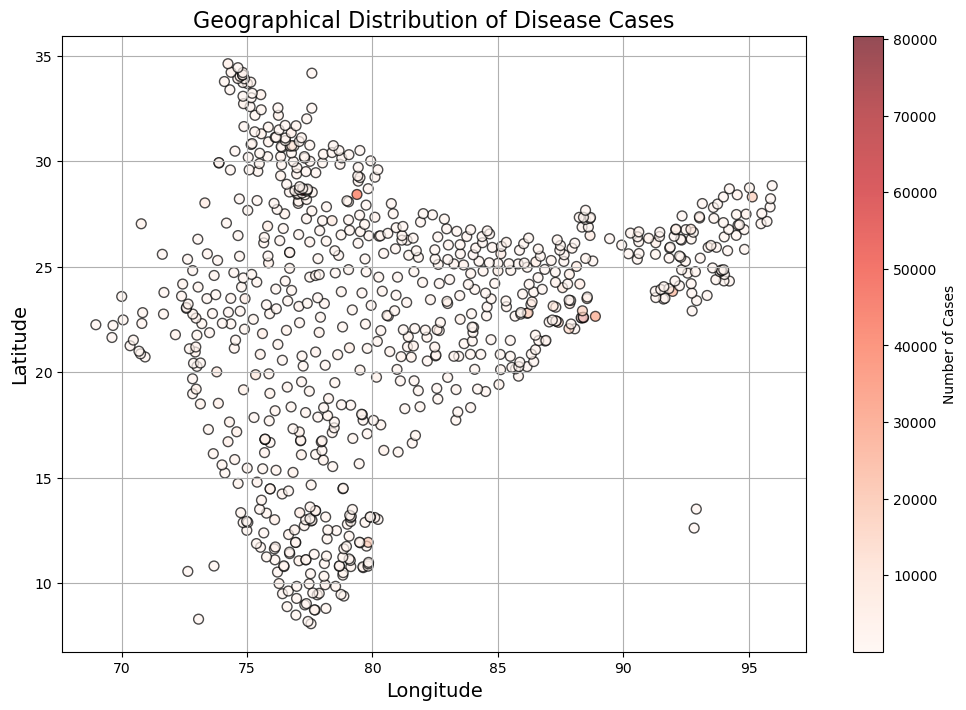

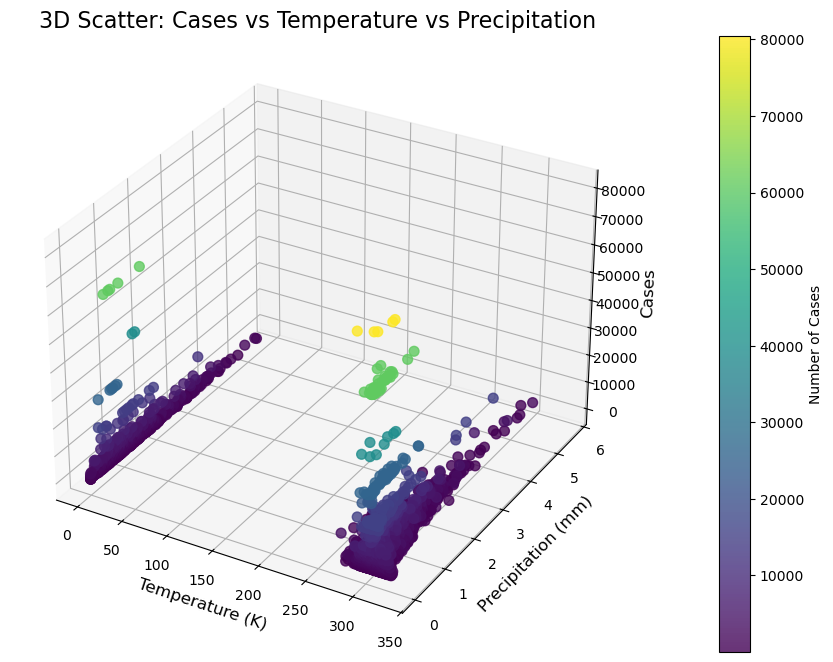

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Load the data
file_path = 'Final_data.csv'  # Adjust path as needed
data = pd.read_csv(file_path)

# Data Cleaning and Preparation
data['Cases'] = pd.to_numeric(data['Cases'], errors='coerce')
data['Deaths'] = data['Deaths'].fillna(0).astype(int)
data['date'] = pd.to_datetime(data[['year', 'mon', 'day']].rename(columns={'mon': 'month', 'day': 'day', 'year': 'year'}))

# Time Series Analysis
time_series_data = data.groupby('date').agg({'Cases': 'sum', 'Deaths': 'sum', 'Temp': 'mean', 'preci': 'mean'}).reset_index()

# Calculate moving averages for smoothing
window_size = 100  # Define the rolling window size (7 days for weekly average)
time_series_data['Cases_Smooth'] = time_series_data['Cases'].rolling(window=window_size, center=True).mean()
time_series_data['Deaths_Smooth'] = time_series_data['Deaths'].rolling(window=window_size, center=True).mean()

# Plotting Cases
plt.figure(figsize=(14, 6))
plt.plot(time_series_data['date'], time_series_data['Cases_Smooth'], label=f'{window_size}-Day Average Cases', color='blue', linewidth=2)
plt.title('Daily Cases and Smoothed Trend', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Cases', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.savefig("cases_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()

# Plotting Deaths
plt.figure(figsize=(14, 6))
plt.plot(time_series_data['date'], time_series_data['Deaths_Smooth'], label=f'{window_size}-Day Average Deaths', color='red', linewidth=2)
plt.title('Daily Deaths and Smoothed Trend', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Deaths', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.savefig("deaths_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()

# Plotting Temperature and Precipitation
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(time_series_data['date'], time_series_data['Temp'], label='Temperature', color='orange', linewidth=2)
ax1.set_xlabel('Date', fontsize=14)
ax1.set_ylabel('Temperature (K)', fontsize=14, color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax2 = ax1.twinx()
ax2.plot(time_series_data['date'], time_series_data['preci'], label='Precipitation', color='blue', linewidth=2, linestyle='--')
ax2.set_ylabel('Precipitation (mm)', fontsize=14, color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
fig.suptitle('Time Series of Temperature and Precipitation', fontsize=16)
fig.tight_layout()
plt.grid(True)
plt.savefig("temperature_precipitation_timeseries.png", dpi=300, bbox_inches='tight')
plt.show()

# Scatter Plot for Geographical Distribution of Cases
geo_data = data.groupby(['Latitude', 'Longitude', 'state_ut']).agg({'Cases': 'sum', 'Deaths': 'sum'}).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(geo_data['Longitude'], geo_data['Latitude'], c=geo_data['Cases'], cmap='Reds', s=50, alpha=0.7, edgecolors="k")
plt.title('Geographical Distribution of Disease Cases', fontsize=16)
plt.xlabel('Longitude', fontsize=14)
plt.ylabel('Latitude', fontsize=14)
plt.colorbar(label='Number of Cases')
plt.grid(True)
plt.savefig("geographical_distribution_cases.png", dpi=300, bbox_inches='tight')
plt.show()

# 3D Visualization: Cases vs Temperature vs Precipitation
geo_climatic_data = geo_data.merge(data[['Latitude', 'Longitude', 'Temp', 'preci']].drop_duplicates(), on=['Latitude', 'Longitude'], how='left').fillna(0)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(geo_climatic_data['Temp'], geo_climatic_data['preci'], geo_climatic_data['Cases'], c=geo_climatic_data['Cases'], cmap='viridis', s=50, alpha=0.8)
ax.set_title('3D Scatter: Cases vs Temperature vs Precipitation', fontsize=16)
ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Precipitation (mm)', fontsize=12)
ax.set_zlabel('Cases', fontsize=12)
fig.colorbar(sc, ax=ax, pad=0.1, label='Number of Cases')
plt.savefig("3d_cases_temp_precip.png", dpi=300, bbox_inches='tight')
plt.show()
